In [1]:
#Import packages used
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

#Reload custom modules if being tested
import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

## gLV
This section shows how an interaction is defined in a simple two-species predator prey Lotka Volterra model.

In [543]:
def gLV(t, y, intMat, GRs):
    pcgrs = np.array([GRs[alph] + np.sum([intMat[alph,bet]*y[bet] for bet in range(len(y))]) for alph in range(len(y))])
    return np.multiply(pcgrs,y)

def simGLV(intMat,GRs,dt,x0,delX):
    tMax = 120
    tSteps = np.arange(0,tMax,dt)
    
    solutionA = solve_ivp(fun=gLV,t_span=[0,tMax],y0=x0,args=(intMat,GRs),t_eval=tSteps)

    tMax = 400
    tSteps = np.arange(0,tMax,dt)

    #Add perturbation to abundances
    midpoint = solutionA.y[:,-1]
    midpoint[0] = midpoint[0] + delX
    
    solutionB = solve_ivp(fun=gLV,t_span=[0,tMax],y0=midpoint,args=(intMat,GRs),t_eval=tSteps)
    
    return np.concatenate((solutionA.y,solutionB.y),axis=1)   

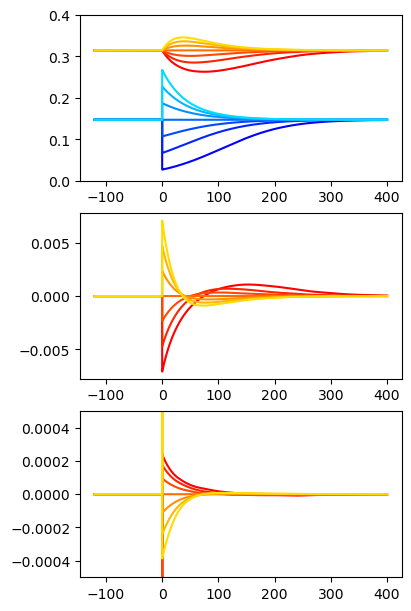

In [549]:
fig, axAr = plt.subplots(nrows = 3, ncols = 1, constrained_layout = True, figsize=(4,6))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

intMat = np.array([[-0.08582559, -0.0365755 ],[ 0.05897309, -0.10078681]])
#intMat = np.array([[-1,0.8],[-0.2,-1]])
GRs = np.array([0.02414158, 0.02299777])
#GRs = np.array([0.8,-0.1])
dt = 0.01
tMax = 520
tRange = np.arange(0,tMax,dt)-120

rateStore = np.zeros((7,1))

for ind, delX in enumerate(np.arange(-0.12,0.13,0.04)):
    dynamics = simGLV(intMat,GRs,dt,np.array([0.14731099, 0.314378]),delX)
    ax1.plot(tRange,dynamics[0,:].T,color = (0,ind/7,1))
    ax1.plot(tRange,dynamics[1,:].T,color = (1,ind/7,0))

    pcgrs = np.array([GRs[1] + dynamics[0,tInd]*intMat[1,0] + dynamics[1,tInd]*intMat[1,1] for tInd in range(int(tMax/dt))])
    ax2.plot(tRange,pcgrs,color = (1,ind/7,0))
    rateStore[ind] = pcgrs[int(120/dt)]

    pcgas = np.diff(pcgrs)/dt
    ax3.plot(tRange[0:-1],pcgas,color = (1,ind/7,0))

ax1.set_ylim([0,0.4])
ax3.set_ylim([-0.0005,0.0005])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\gLV_Example.pdf")

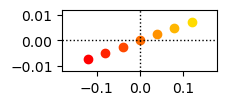

In [553]:
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(2, 0.8)

for ind, delX in enumerate(np.arange(-0.12,0.13,0.04)):
    plt.plot(delX,rateStore[ind],'o',color=(1,ind/7,0))

plt.ylim([-0.012,0.012])
plt.xlim([-0.18,0.18])
plt.axhline(y=0, color='k', linestyle=':', linewidth = 1)
plt.axvline(x=0, color='k', linestyle=':', linewidth = 1)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\gLV_Interacts.pdf")

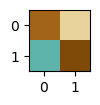

In [559]:
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(0.8, 0.8)
plt.imshow(intMat,cmap='BrBG',vmin=-0.12,vmax=0.12)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\Mini_interactMat.pdf")

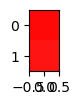

In [561]:
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(0.8, 0.8)
plt.imshow(np.expand_dims(GRs,axis=1),cmap='bwr',vmin=-0.025,vmax=0.025)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\Mini_GRvec.pdf")

## EO
This section shows how a similar interaction structure in an Environment Organism (EO) model results in intertial interactions. Base model is the auxotrophy model with two species.

In [317]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmax*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[specInd,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmax
    sensGrad[specInd] = dMonodA*monodG*Vmax
    
    return sensGrad
    
#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmax*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmax*monodG

    return impact

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In [515]:
#2-species function test
#Kms = np.array([[0.9,0,1.2],[0,1.5,1.5]])
#Ys = np.array([[4,0,1],[0,10,1]])
#Cs = np.array([[0,0.02,-1],[0.01,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Kms = np.array([[2,0,1.5],[0,0.9,1.2]])
Ys = np.array([[20,0,1],[0,4,1]])
Cs = np.array([[0,0.08,-1],[0.04,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Vmax = 10

EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

rIn = np.array([0,0,1.0])
sysParams = {'rIn':rIn}

B0 = np.array([0.5,0.5]) #Starting concentration of bacteria in batch (biomass)

noRes = 2
noSpec = 2

#B0 = np.array([0.62113948, 0.43382951]) #Starting concentration of bacteria in batch (biomass)

maxChemT = 500
dilRate = 0.1

chemSimBase = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,rIn)
chemSimBase.set_timeSettings(tSpan = [0,maxChemT], dt=0.01)
chemSimBase.set_dilSettings(D=dilRate,transT=0.1)
chemSimBase.set_instInteract(instInteract)
chemSimBase.set_intrinsicGR(intrinsicGR)
chemSimBase.simEOmodel('Chemostat')

chemSimBase.rStar = chemSimBase.resTimeseries[:,-1]
A = chemSimBase.assembleIntMat(chemSimBase.rStar);
mu = chemSimBase.assembleGRvec(chemSimBase.rStar)

#Use these effective interaction values to parameterise the gLV model above
print(A)
print(mu)
print(-np.matmul(np.linalg.inv(A),mu))

[[-0.08582559 -0.0365755 ]
 [ 0.05897309 -0.10078681]]
[0.02414158 0.02299777]
[0.14731099 0.314378  ]


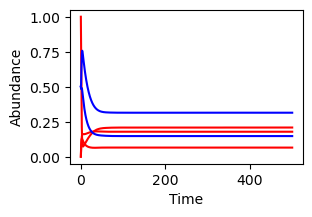

In [517]:
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(3, 2)

chemSimBase.plotSolutionTimecourse()

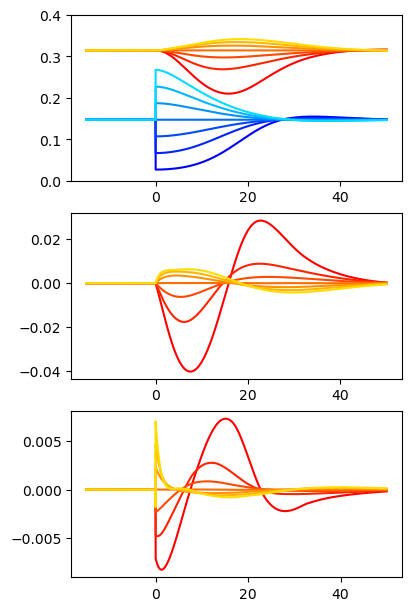

In [519]:
fig, axAr = plt.subplots(nrows = 3, ncols = 1, constrained_layout = True, figsize=(4,6))
ax1=axAr[0]
ax2=axAr[1]
ax3=axAr[2]

accelStore = np.zeros((7,1))

t1 = 15
t2 = 50

tRange = np.arange(0,t1+t2,chemSimBase.dt)-t1

for ind, delX in enumerate(np.arange(-0.12,0.13,0.04)):
    chemSimBase.set_stationaryStart('eEO')
    chemSimBase.set_timeSettings(tSpan = [0,t1], dt=0.01)
    chemSimBase.simEOmodel('Chemostat')
    
    dynamicsAS = chemSimBase.specTimeseries
    dynamicsAG = np.array([sensFunc(chemSimBase.resTimeseries[:,tInd],1,EOparams) for tInd in range(int(t1/chemSimBase.dt))]) - dilRate

    chemSimBase.B0[0] += delX
    chemSimBase.set_timeSettings(tSpan = [0,t2], dt=0.01)
    chemSimBase.simEOmodel('Chemostat')
    dynamicsBS = chemSimBase.specTimeseries
    dynamicsBG = np.array([sensFunc(chemSimBase.resTimeseries[:,tInd],1,EOparams) for tInd in range(int(t2/chemSimBase.dt))]) - dilRate
    
    dynamicsS = np.concatenate((dynamicsAS,dynamicsBS),axis=1)
    dynamicsG = np.concatenate((dynamicsAG,dynamicsBG))
    
    ax1.plot(tRange,dynamicsS[0,:].T,color = (0,ind/7,1))
    ax1.plot(tRange,dynamicsS[1,:].T,color = (1,ind/7,0))

    pcgrs = np.divide(np.diff(dynamics),dynamics[:,0:-1])/chemSimBase.dt
    ax2.plot(tRange,dynamicsG,color = (1,ind/7,0))

    pcgas = np.diff(dynamicsG)/chemSimBase.dt
    ax3.plot(tRange[0:-1],pcgas,color = (1,ind/7,0))
    accelStore[ind] = pcgas[int(t1/chemSimBase.dt)]

ax1.set_ylim([0,0.4])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\EO_Example.pdf")

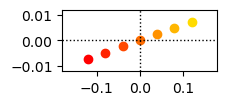

In [523]:
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(2, 0.8)

for ind, delX in enumerate(np.arange(-0.12,0.13,0.04)):
    plt.plot(delX,accelStore[ind],'o',color=(1,ind/7,0))

plt.ylim([-0.012,0.012])
plt.xlim([-0.18,0.18])
plt.axhline(y=0, color='k', linestyle=':', linewidth = 1)
plt.axvline(x=0, color='k', linestyle=':', linewidth = 1)

plt.savefig("G:\\My Drive\\Writing\\Papers\\Accelerando\\Figures\\PDFs\\EO_Interactions.pdf")